# Using SatSim

A personal tutorial and reference for **SatSim**, the GPU-accelerated (TensorFlow-based)
electro-optical space-object image simulator. SatSim renders synthetic focal-plane frames
of stars and resident space objects (RSOs) with a realistic detector-noise chain, and writes
**SatNet**-format annotation / truth files alongside the imagery — its native purpose is
producing *labeled* training data for detection and tracking algorithms.

> **Scope of this notebook (Action Item 1).** SatSim **only**. We do *not* touch synphot,
> DIRSIG, or SatViz/CZML here — those are later action items in
> `docs/adr/0001-hybrid-synphot-satsim-pipeline.md`. This notebook follows the structure of
> SatSim's own readthedocs *Usage* page and adds plain-language commentary on every config block.

**What we cover**

1. Install / import check and a minimal smoke-test call.
2. A minimal working config: site geometry, a single TLE target, a basic star field.
3. Running the image generator (`gen_multi` / `image_generator`) against that config.
4. Inspecting a rendered frame: load the FITS + annotation/truth files, display with a
   log / zscale stretch, and overlay the annotation.
5. A short reference on config structure (`sim`, `fpa`, `geometry` top-level keys).

Throughout, look for **⚠️ Silent-failure** callouts. SatSim performs **no schema validation** on its
config: unknown or misspelled keys are silently ignored and bad values fail quietly rather than
raising. Every callout below was reproduced while building this notebook.

---


## 1. Install / import check and a minimal smoke test

SatSim is installed in the `satsim-env` conda environment (Python 3.10). 

- **On native Windows, TensorFlow ≥ 2.11 has no GPU support** — SatSim falls back to CPU
  and runs fine (GPU would require WSL2.)  

The import below prints the version and confirms the three public entry points resolve.  
- **image_generator** is the actual rendering engine, exposed as a Python generator. Each iteration runs one full frame through the pipeline (render → PSF convolve → noise → A/D → write) and yields the rendered image tensor.  
- **gen_images** drives that engine to completion for one static config — "static" meaning any randomized/dynamic parameters have already been resolved into fixed values. It writes the full SatNet-format output set (FITS, annotations, ground truth) to a directory and returns that directory's path. One call, one complete image/annotation set.  
- **gen_multi** is the one the tutorial notebook actually calls, and the one you'd use for real dataset generation. It reads ssp['sim']['samples'] and produces that many independent sets — internally resolving each sample's dynamic parameters into its own static config, then running the gen_images logic per sample, with device/pid arguments to spread the work across GPUs or processes.

In [24]:
import warnings
warnings.filterwarnings("ignore")  # silence benign TF / numpy deprecation chatter for a clean tutorial

import satsim
from satsim import gen_multi, gen_images, image_generator

print("SatSim version:", satsim.__version__)
print("Entry points:", [f.__name__ for f in (gen_multi, gen_images, image_generator)])

SatSim version: 0.25.2
Entry points: ['gen_multi', 'gen_images', 'image_generator']


### Minimal smoke test

The smallest meaningful call that exercises SatSim's radiometric core (no rendering, no files):
convert a visual magnitude to **photoelectrons/second** through the sensor zeropoint using
`mv_to_pe`. This is the exact function the renderer uses to turn an object's `mv` into signal, so
if it runs, the numerical stack is healthy.

`mv_to_pe(zeropoint, mv)` implements `pe = 10 ** (-0.4 * (mv - zeropoint))`. A brighter (smaller)
magnitude yields more photoelectrons.

In [25]:
from satsim.image.fpa import mv_to_pe

zeropoint = 20.6663  # instrumental zeropoint: the magnitude that produces 1 pe/s
for mv in (8.0, 12.0, 16.0):
    print(f"mv={mv:5.1f}  ->  {mv_to_pe(zeropoint, mv):12.1f} pe/s")

mv=  8.0  ->      116552.1 pe/s
mv= 12.0  ->        2927.7 pe/s
mv= 16.0  ->          73.5 pe/s


## 2. A minimal working config

A SatSim configuration is a plain Python `dict` (equivalently a JSON/YAML file). The top-level keys
are `version`, `sim`, `fpa`, `background`, and `geometry` (plus optional `clouds` / `radar`, unused
here). We build the dict inline and annotate every block.

Our scenario: a **ground telescope** on Maui **rate-tracking a single satellite** given by a TLE, so
the satellite sits as a fixed point at frame center while the star field streaks behind it. We use
the canonical Vallado / `sgp4` example TLE for the ISS (its checksums are valid and it ships with the
`sgp4` test suite), and set the scene time **to that TLE's epoch**, computed programmatically in section 2d.

In [26]:
# --- The target's two-line element set (canonical sgp4 example TLE; valid checksums) ---
TLE1 = "1 25544U 98067A   08264.51782528 -.00002182  00000-0 -11606-4 0  2927"
TLE2 = "2 25544  51.6416 247.4627 0006703 130.5360 325.0288 15.72125391563537"

### 2a. `sim` — the simulation / rendering controls

Governs *how* the scene is rendered and *what* gets written out.

| key | meaning |
|---|---|
| `mode` | render algorithm. `fftconv2p` = FFT convolution of the oversampled scene with the PSF (the general-purpose default). |
| `spatial_osf` | spatial oversampling factor. The scene is rendered on a grid `spatial_osf`× finer than the detector, then binned down — this is what gives sub-pixel-accurate PSFs and streaks. `3` is a light, fast choice; production configs often use `5`+. |
| `temporal_osf` | how finely each exposure is subdivided in time (for motion within a frame). `"auto"` lets SatSim pick based on how far objects move per frame. |
| `padding` | extra oversampled-pixel border kept around the FPA so objects/PSF wings just outside the field still contribute. |
| `samples` | number of independent image *sets* to generate from this config (Monte-Carlo). `1` here. |
| `save_jpeg` / `save_movie` | write annotated JPEG previews / an animated PNG. |
| `save_ground_truth` | write per-frame float32 truth planes (target/star/background/noise) as `.tiff`. |
| `save_czml` | write a Cesium CZML scene file — **left off here** (that's a later action item). |

In [27]:
sim = {
    "mode": "fftconv2p",
    "spatial_osf": 3,
    "temporal_osf": "auto",
    "padding": 100,
    "samples": 1,
    "save_jpeg": True,
    "save_movie": False,
    "save_ground_truth": True,
    "save_czml": False,
}

### 2b. `fpa` — the focal-plane array (detector + optics + timing)

Describes the sensor: geometry, radiometry, noise, PSF, and the frame cadence.

| key | meaning |
|---|---|
| `height`, `width` | detector size in pixels. |
| `y_fov`, `x_fov` | field of view in **degrees** (so pixel IFOV = `y_fov / height`). |
| `dark_current` | dark signal in e⁻/pixel/second. |
| `gain`, `bias` | pre-A/D electron gain and additive bias. |
| `zeropoint` | magnitude that yields 1 pe/s — sets the absolute brightness scale (same value we smoke-tested). |
| `a2d` | analog-to-digital block: `response` curve, full-well capacity `fwc`, digital `gain` (e⁻/DN), and `bias` (DN pedestal added to every pixel). |
| `noise` | `read` noise (e⁻ RMS) and `electronic` (extra fixed electronic noise). |
| `psf` | point-spread function. `mode: gaussian` with `eod` = *ensquared-energy-on-detector* fraction, a compact way to specify PSF width. |
| `time` | `exposure` seconds per frame and `gap` seconds of dead time between frames. |
| `num_frames` | frames per set. |

The pixel background pedestal you'll see in the FITS (~1500–1600 DN) is `a2d.bias` plus dark/sky
signal — not zero.

In [28]:
fpa = {
    "height": 512,
    "width": 512,
    "y_fov": 0.5,          # degrees
    "x_fov": 0.5,
    "dark_current": 0.3,   # e-/pixel/s
    "gain": 1.0,
    "bias": 0.0,
    "zeropoint": 20.6663,
    "a2d": {"response": "linear", "fwc": 100000, "gain": 1.5, "bias": 1500},
    "noise": {"read": 9.0, "electronic": 0.0},
    "psf": {"mode": "gaussian", "eod": 0.15},
    "time": {"exposure": 5.0, "gap": 2.5},   # seconds
    "num_frames": 4,
}

### 2c. `background` — diffuse sky brightness

A uniform sky background in magnitude-per-square-arcsecond terms. `galactic` sets the diffuse level;
`stray`/`moon`/`twilight`/`daytime` sub-models are available but left at `none` for a clean night sky.
A larger magnitude = fainter sky.

In [29]:
background = {
    "galactic": 19.5,
    "stray": {"mode": "none"},
}

### 2d. Deriving the scene time from the TLE epoch (programmatically)

`geometry.time` is a `[year, month, day, hour, minute, second]` UTC list — which is exactly the argument
list SatSim feeds to Skyfield's `ts.utc(...)`. Rather than hand-transcribe a date, we can compute it
straight from the target's TLE.

A TLE encodes its **epoch** in line 1, columns 19–32, as `YYDDD.DDDDDDDD` (2-digit year + fractional
day-of-year). Parsing that by hand is error-prone (the year pivots at 57: `57–99`→`19xx`, `00–56`→`20xx`),
so we let Skyfield parse it and read back the UTC calendar tuple. Using the TLE's **own epoch** as the
scene time is also the most accurate choice — SGP4 propagation error grows the further you get from epoch.

In [30]:
from skyfield.api import load, EarthSatellite

def tle_epoch_to_geometry_time(tle_line1, tle_line2, ts=None):
    """Convert a TLE's epoch to SatSim's `geometry.time` form: [Y, M, D, h, m, s] in UTC.

    The returned list is exactly what SatSim passes to Skyfield's `ts.utc(...)`
    internally, so it round-trips through `satsim.time.utc_from_list` without loss.
    """
    ts = ts or load.timescale()
    sat = EarthSatellite(tle_line1, tle_line2, ts=ts)
    y, mo, d, h, mi, s = sat.epoch.utc          # Skyfield CalendarTuple, UTC
    return [int(y), int(mo), int(d), int(h), int(mi), float(s)]

scene_time = tle_epoch_to_geometry_time(TLE1, TLE2)
print("TLE epoch as geometry.time:", scene_time)

# sanity check: it round-trips through SatSim's own converter
from satsim import time as satsim_time
print("round-trips to:", satsim_time.utc_from_list(scene_time).utc_iso())

TLE epoch as geometry.time: [2008, 9, 20, 12, 25, 40.10418701171875]
round-trips to: 2008-09-20T12:25:40Z


### 2e. Pointing a manual track mode (`fixed` / `radec`) at the target

`rate`, `sidereal`, and `rate-sidereal` all read the target's `tle` and aim the telescope for you. The
other two modes — `fixed` (constant az/el) and `radec` (constant ra/dec) — are **manual pointing**:
they ignore the TLE and stare wherever you tell them. Leave the pointing out and it defaults to
`(0, 0)` — the due-north horizon — so the target misses the field entirely and SatSim renders an
**empty frame** (zero annotated objects). That empty annotation is exactly what makes the inspection
cell in section 4 raise `IndexError: list index out of range`.

The catch — and the reason manual pointing takes real thought — is that to aim at the target you must
already know **where the target will be**, i.e. propagate the TLE yourself. The helper below does
exactly the SGP4 topocentric computation the auto modes do internally, evaluated at the scene start,
and hands back both an az/el (for `fixed`) and an ra/dec (for `radec`). Because these modes then
**hold** that pointing, a fast LEO target still drifts out of a narrow FOV over a sequence — which is
precisely why `rate` exists.

In [31]:
from skyfield.api import load, wgs84, EarthSatellite

def target_pointing_from_tle(tle1, tle2, lat_deg, lon_deg, alt_km, geometry_time, ts=None):
    """Where do I aim a *manual* track mode so it looks straight at a TLE target?

    WHY THIS IS NEEDED (and why manual pointing is genuinely fiddly)
    ---------------------------------------------------------------
    SatSim's five track modes split into two camps:

      * rate / sidereal / rate-sidereal  -> you hand them the target's `tle`, and SatSim
        propagates it with SGP4 and aims the boresight for you. The target is in the field
        automatically. These are the "point for me" modes.

      * fixed  (stares at a constant azimuth / elevation) and
        radec  (stares at a constant right-ascension / declination)
        -> these IGNORE the tle. They point wherever you tell them, and hold still. If you
        don't tell them, az/el (or ra/dec) default to 0 -> the telescope stares at the
        due-north horizon, the target is nowhere near the FOV, and the frame comes out
        EMPTY (zero annotated objects). That empty frame is the usual "why did fixed break?"

    So to aim fixed/radec at the target you must first work out *where the target is* -- which
    is exactly the SGP4 topocentric propagation the auto modes were quietly doing for you.
    This helper does that once, at the scene start, and returns BOTH conventions so you can
    drop the numbers straight into a `fixed` or `radec` track block.

    THINGS THAT MAKE THIS HARDER THAN IT LOOKS
    ------------------------------------------
      * It's a single instant. fixed/radec HOLD this pointing; they do not follow the target.
        The ISS moves ~0.5-1 deg/s on the sky, so across a multi-frame sequence it streaks
        through and then leaves a narrow FOV. (That drift is the whole reason `rate` exists.)
      * `el` can be negative -- at this TLE's epoch the ISS is below the local horizon. SatSim
        renders it anyway (it does not enforce visibility), so you still get a frame.
      * RA is returned in DEGREES here (0-360), because SatSim's radec mode wants degrees, not
        the hours astronomers usually quote.
      * This is a geometric/apparent aim good to a small fraction of the FOV -- enough to land
        the target on the detector, not a guarantee of the exact centroid.
    """
    ts   = ts or load.timescale()
    sat  = EarthSatellite(tle1, tle2, ts=ts)
    site = wgs84.latlon(lat_deg, lon_deg, elevation_m=alt_km * 1000.0)  # matches geometry.site below
    t    = ts.utc(*geometry_time)                    # the exact instant geometry['time'] encodes
    topo = (sat - site).at(t)                        # observer -> target line of sight at t

    alt, az, _  = topo.altaz()                       # -> fixed  (az, el), degrees
    ra,  dec, _ = topo.radec()                       # -> radec  (ra, dec); .degrees gives 0-360 / -90..90

    return {"az": float(az.degrees), "el":  float(alt.degrees),
            "ra": float(ra.degrees), "dec": float(dec.degrees)}

# Aim at our ISS target, using the SAME site + time the scene uses (Maui; scene_time from 2d).
pointing = target_pointing_from_tle(TLE1, TLE2, 20.7, -156.3, 3.0, scene_time)
print("fixed  -> az = %8.3f deg,  el = %8.3f deg" % (pointing["az"], pointing["el"]))
print("radec  -> ra = %8.3f deg, dec = %8.3f deg" % (pointing["ra"], pointing["dec"]))
print("(el < 0 => target is below the local horizon at the TLE epoch; SatSim renders it anyway)")

fixed  -> az =  322.995 deg,  el =  -19.200 deg
radec  -> ra =  254.512 deg, dec =   36.118 deg
(el < 0 => target is below the local horizon at the TLE epoch; SatSim renders it anyway)


### 2f. `geometry` — time, observer, stars, and targets

The physical scene. This is the block that turns SatSim from an abstract focal-plane into real
astrometry.

- **`time`** — UTC scene start as `[Y, M, D, h, m, s]`.
- **`site`** — the observer and where the telescope points:
  - `lat`/`lon`/`alt` (degrees, degrees, km) define a ground site.
  - `gimbal.rotation` rotates the focal plane.
  - `track.mode` sets the tracking law, and the five modes fall into **two groups**:
    - **Point-for-you (read the `tle`):** `rate` follows the target (target is a **point**, stars
      **streak**), `sidereal` holds on the stars (stars are points, the target streaks), and
      `rate-sidereal` does rate then switches to sidereal. All three take the target's `tle`.
    - **Manual pointing (ignore the `tle`):** `fixed` stares at a constant **az/el**, `radec` at a
      constant **ra/dec**. You supply the pointing yourself — section 2e computes it from the TLE.
      Omit it and the boresight defaults to (0, 0) (due-north horizon): the target misses the field
      and you get an **empty frame**.
- **`stars`** — the star field. `mode: bins` synthesizes a random field from a magnitude histogram:
  `mv.bins` are the magnitude bin **edges** and `mv.density` the count per bin (stars/deg²).
  `motion.mode` here is `none` because, with a real `site`, SatSim computes the on-sky star motion
  from the tracking geometry itself.
- **`obs`** — the list of rendered objects. Each entry sets a `mode` and a brightness. Our one entry
  is `mode: tle` with the same TLE as the track and `mv: 10.0`.

> **⚠️ Silent-failure (bin edges vs. counts).** In `bins` mode, `mv.bins` holds **N+1 edges** and
> `mv.density` holds **N counts** — note the deliberate off-by-one below (9 edges, 8 densities).
> Get this wrong and SatSim will not complain; it just zips the two lists and silently drops the
> extra edge.

In [36]:
geometry = {
    "time": scene_time,                 # UTC, derived from the TLE epoch (section 2d)
    "site": {
        "lat": 20.7,     # deg N  (Haleakala, Maui)
        "lon": -156.3,   # deg E
        "alt": 3.0,      # km
        "gimbal": {"rotation": 0.0},
        # --- Pick ONE track mode below. rate / sidereal / rate-sidereal read the TLE and aim
        #     for you; fixed / radec are MANUAL pointing (section 2e) and use `pointing`, which
        #     was computed from the TLE. Uncomment exactly one: ---
        # "track": {"mode": "rate",          "tle": [TLE1, TLE2], "name": "ISS"},
        # "track": {"mode": "sidereal",      "tle": [TLE1, TLE2], "name": "ISS"},
        # "track": {"mode": "rate-sidereal", "tle": [TLE1, TLE2], "name": "ISS"},
        "track": {"mode": "fixed", "az": pointing["az"], "el":  pointing["el"]},   # manual: az/el
        # "track": {"mode": "radec", "ra": pointing["ra"], "dec": pointing["dec"]},  # manual: ra/dec
    },
    "stars": {
        "mode": "bins",
        "mv": {
            "bins":    [10, 11, 12, 13, 14, 15, 16, 17, 18],          # 9 edges
            "density": [5.0, 10.3, 24.3, 35.2, 60.0, 110.1, 180.3, 285.5],  # 8 counts (N = edges - 1)
        },
        "motion": {"mode": "none"},
    },
    "obs": {
        "mode": "list",
        "list": [
            {"mode": "tle", "tle": [TLE1, TLE2], "mv": 10.0, "name": "ISS"},
        ],
    },
}

ssp = {"version": 1, "sim": sim, "fpa": fpa, "background": background, "geometry": geometry}
print("Config assembled. Top-level keys:", list(ssp.keys()))

Config assembled. Top-level keys: ['version', 'sim', 'fpa', 'background', 'geometry']


> **⚠️ Silent-failure (unknown / misspelled keys).** Because there is no schema, a typo like
> `spatal_osf` or putting the target brightness under `magnitude` instead of `mv` raises **no error**.
> The mis-keyed value is simply ignored: a typo'd `sim` key leaves the real default in place, and a
> target with no valid `mv`/`pe` renders with **zero** photoelectrons — it silently vanishes from the
> frame, the only hint being an unrelated `divide by zero encountered in log10` warning from the
> magnitude bookkeeping. Always eyeball the rendered frame and the annotation object count.

> **⚠️ Silent-failure (illumination is not modeled by default).** SatSim renders the target from its
> `mv` regardless of whether it is physically sunlit or in Earth's shadow. Umbra masking only happens
> if you set `sim.enable_earth_shadow: true`. Don't assume a "night-side" target will be dark.

## 3. Running the image generator

Three entry points, increasing in level:

- **`image_generator(ssp, ...)`** — a *generator* that yields one rendered frame at a time
  (`fpa_digital`, annotation metadata, truth planes, …). Use it to stream frames into your own code
  without writing files. It expects an **already-transformed** config.
- **`gen_images(ssp, ...)`** — renders one set and writes SatNet files. Also expects a transformed config.
- **`gen_multi(ssp, ...)`** — the top-level driver: it **transforms** the config (evaluating any random
  samplers / references), then loops `sim.samples` times calling `gen_images`. This is what we call.

> **Note (`eager` argument).** All three take `eager=`, but SatSim's own docstring says it *"Has no
> effect. True only."* — SatSim always runs TensorFlow eagerly. Leave it at the default.

> **Note (first-run download).** On the first call, Skyfield downloads the JPL `de421.bsp` ephemeris
> (~17 MB) to the working directory. This needs network access once; subsequent runs are offline.

We write outputs to `./output/` next to the notebook, under the folder name `tutorial_run`.

In [37]:
import os, glob

output_dir = os.path.abspath("output")
os.makedirs(output_dir, exist_ok=True)

gen_multi(ssp, eager=True, output_dir=output_dir, folder_name="tutorial_run")

run_dir = os.path.join(output_dir, "tutorial_run")
print("Wrote output set to:", run_dir, "\n")
for root, _dirs, files in os.walk(run_dir):
    for f in sorted(files):
        rel = os.path.relpath(os.path.join(root, f), run_dir)
        print("  ", rel)

Wrote output set to: c:\Users\kevin.kearney\code\SatSim\notebooks\output\tutorial_run 

   config.json
   config_pass_1.json
   config_pass_2.json
   config_pass_3.json
   config_pass_4.json
   config_pass_5.json
   config_pass_6.json
   config_pass_7.json
   AnnotatedImages\tutorial_run.0000.jpg
   AnnotatedImages\tutorial_run.0001.jpg
   AnnotatedImages\tutorial_run.0002.jpg
   AnnotatedImages\tutorial_run.0003.jpg
   Annotations\tutorial_run.0000.json
   Annotations\tutorial_run.0000.tiff
   Annotations\tutorial_run.0001.json
   Annotations\tutorial_run.0001.tiff
   Annotations\tutorial_run.0002.json
   Annotations\tutorial_run.0002.tiff
   Annotations\tutorial_run.0003.json
   Annotations\tutorial_run.0003.tiff
   ImageFiles\tutorial_run.0000.fits
   ImageFiles\tutorial_run.0001.fits
   ImageFiles\tutorial_run.0002.fits
   ImageFiles\tutorial_run.0003.fits


### What was written

SatSim's SatNet output layout:

- **`ImageFiles/*.fits`** — the rendered sensor frames (16-bit DN), one per frame.
- **`Annotations/*.json`** — per-frame annotations: object list (class, bounding box, magnitude,
  RA/Dec, SNR) plus sensor and frame metadata.
- **`Annotations/*.tiff`** — float32 ground-truth planes (written because `save_ground_truth: True`).
- **`AnnotatedImages/*.jpg`** — auto-stretched previews with boxes drawn (because `save_jpeg: True`).
- **`config.json`** + **`config_pass_*.json`** — the final transformed config and each intermediate
  transform pass, invaluable for debugging what SatSim *actually* ran versus what you wrote.

## 4. Inspecting a rendered frame

Now we load frame 0 directly — the raw FITS, the annotation JSON, and the ground-truth TIFF — and
display it ourselves rather than relying on the auto-generated JPEG.

In [38]:
import json
import numpy as np
from astropy.io import fits

frame_stub = "tutorial_run.0000"
fits_path = os.path.join(run_dir, "ImageFiles", frame_stub + ".fits")
anno_path = os.path.join(run_dir, "Annotations", frame_stub + ".json")

img = fits.getdata(fits_path).astype(np.float64)
anno = json.load(open(anno_path))["data"]

print("FITS frame shape:", img.shape)
print(f"DN  min / median / max: {img.min():.0f} / {np.median(img):.0f} / {img.max():.0f}")
objs = anno["objects"]
print("Annotation object count:", len(objs))

# A manual-pointing mode (fixed / radec) aimed away from the target -- or any config that puts
# nothing in the field -- produces an EMPTY object list. Guard against it so cycling through the
# five track modes never hard-crashes here (the bare `objs[0]` used to raise IndexError).
if objs:
    obj = objs[0]
    print("First object:",
          {k: obj[k] for k in ("class_name", "magnitude", "snr", "y_center", "x_center")})
else:
    print("No annotated objects -- nothing landed in the field of view.")
    print("If you switched to a `fixed`/`radec` track mode, check the pointing (section 2e):")
    print("a manual mode with no/wrong az-el or ra-dec stares off-target and renders an empty sky.")

FITS frame shape: (512, 512)
DN  min / median / max: 1574 / 1621 / 2206
Annotation object count: 1
First object: {'class_name': 'Satellite', 'magnitude': 10.0, 'snr': [4.3, 6.55, 7.47, 7.7, 7.72, 7.63, 7.45, 7.18, 7.21, 7.47, 7.64, 7.72, 7.7, 7.58, 7.36, 7.07, 7.0, 7.31, 7.54, 7.68, 7.72, 7.67, 7.51, 7.27, 6.94, 7.11, 7.4, 7.6, 7.7, 7.71, 7.62, 7.44, 7.17, 7.22, 7.48, 7.65, 7.72, 7.69, 7.57, 7.36, 7.06, 7.0, 7.31, 7.54, 7.68, 7.72, 7.66, 7.51, 7.27, 6.95, 7.11, 7.39, 7.59, 7.7, 7.71, 7.63, 7.45, 7.18, 7.2, 7.46, 7.64, 7.71, 7.69, 7.58, 7.37, 7.08, 6.97, 7.29, 7.52, 7.67, 7.71, 7.67, 7.53, 7.3, 6.98, 7.07, 7.35, 7.54, 7.63, 7.67, 7.63, 7.47, 7.21, 6.88, 7.16, 7.43, 7.62, 7.7, 7.7, 7.6, 7.41, 7.13, 7.24, 7.49, 7.65, 7.71, 7.68, 7.56, 7.34, 7.05, 7.0, 7.31, 7.54, 7.67, 7.71, 7.66, 7.51, 7.28, 7.08, 7.37, 7.58, 7.69, 7.71, 7.63, 7.46, 7.2, 7.02, 6.54, 5.59, 5.44, 6.34, 7.29, 7.38, 7.13, 6.9, 7.22, 7.47, 7.62, 7.69, 7.68, 7.56, 7.35, 7.06, 6.98, 7.29, 7.52, 7.66, 7.71, 7.66, 7.53, 7.3, 6.99

### Displaying with a stretch

Raw astronomical frames are dominated by the background pedestal, so a linear display looks blank. We
apply two common stretches with `astropy.visualization`:

- **ZScale** — the IRAF/DS9 algorithm that picks limits around the median for a balanced view.
- **Log** — compresses dynamic range so faint stars and the bright target are visible together.

We show them side by side.

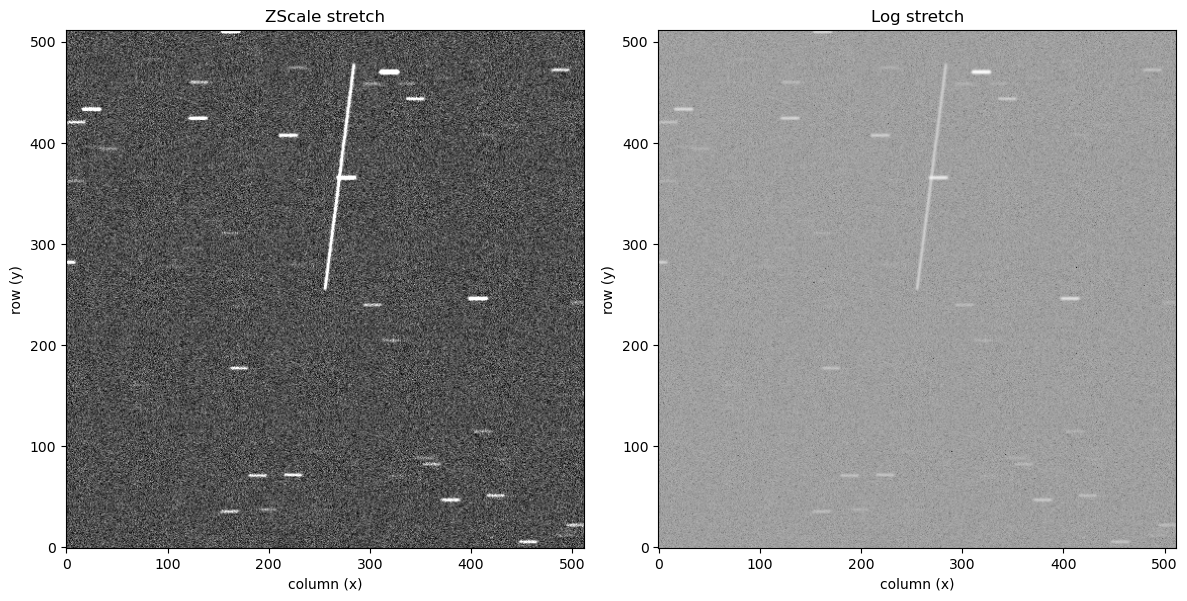

In [39]:
import matplotlib.pyplot as plt
from astropy.visualization import ZScaleInterval, ImageNormalize, LogStretch, MinMaxInterval

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

znorm = ImageNormalize(img, interval=ZScaleInterval())
axes[0].imshow(img, origin="lower", cmap="gray", norm=znorm)
axes[0].set_title("ZScale stretch")

lognorm = ImageNormalize(img, interval=MinMaxInterval(), stretch=LogStretch())
axes[1].imshow(img, origin="lower", cmap="gray", norm=lognorm)
axes[1].set_title("Log stretch")

for ax in axes:
    ax.set_xlabel("column (x)"); ax.set_ylabel("row (y)")
plt.tight_layout(); plt.show()

### Overlaying the annotation

The annotation gives object positions as **fractions of the frame** (0–1), *not* pixels — a genuine
gotcha. To draw them we multiply `x_*` by width and `y_*` by height. `x` maps to column, `y` to row.
Our rate-tracked target is a point at frame center, so its bounding box has ~zero area; we mark its
center and, for any extended object, also draw the box.

> **⚠️ Silent-failure (normalized coordinates).** If you overlay the raw annotation numbers assuming
> pixels, every marker collapses into the bottom-left few pixels and you'll wrongly conclude the
> render is broken. Always scale by `width` / `height` first.

Note also that **stars are rendered but not annotated** by default — the annotation lists only the
target. Set `sim.star_annotation_threshold` to include stars.

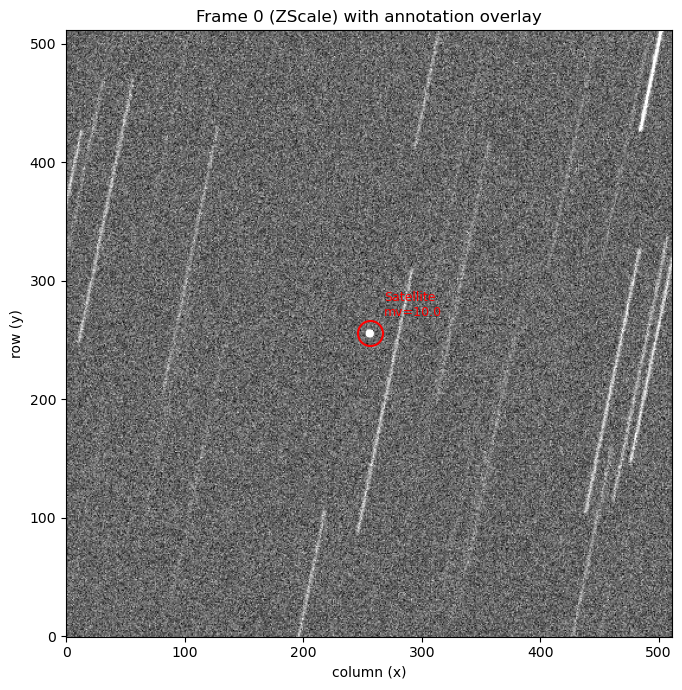

In [13]:
from matplotlib.patches import Rectangle

H, W = img.shape
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(img, origin="lower", cmap="gray", norm=znorm)

for o in anno["objects"]:
    xc, yc = o["x_center"] * W, o["y_center"] * H
    x0, y0 = o["x_min"] * W, o["y_min"] * H
    bw, bh = (o["x_max"] - o["x_min"]) * W, (o["y_max"] - o["y_min"]) * H
    ax.plot(xc, yc, marker="o", mfc="none", mec="red", ms=18, mew=1.5)
    if bw > 1 or bh > 1:                       # draw a box only if the object is extended
        ax.add_patch(Rectangle((x0, y0), bw, bh, fill=False, ec="red", lw=1.2))
    ax.text(xc + 12, yc + 12, f'{o["class_name"]}\nmv={o["magnitude"]:.1f}',
            color="red", fontsize=9, va="bottom")

ax.set_title("Frame 0 (ZScale) with annotation overlay")
ax.set_xlabel("column (x)"); ax.set_ylabel("row (y)")
plt.tight_layout(); plt.show()

### Peeking at the ground-truth planes

With `save_ground_truth: True`, each frame also gets a float32 multi-plane `.tiff` holding the
noiseless truth components. This is the label source when the noisy FITS is too ambiguous to
annotate by hand.

Ground-truth TIFF shape: (9, 512, 512) dtype: float32


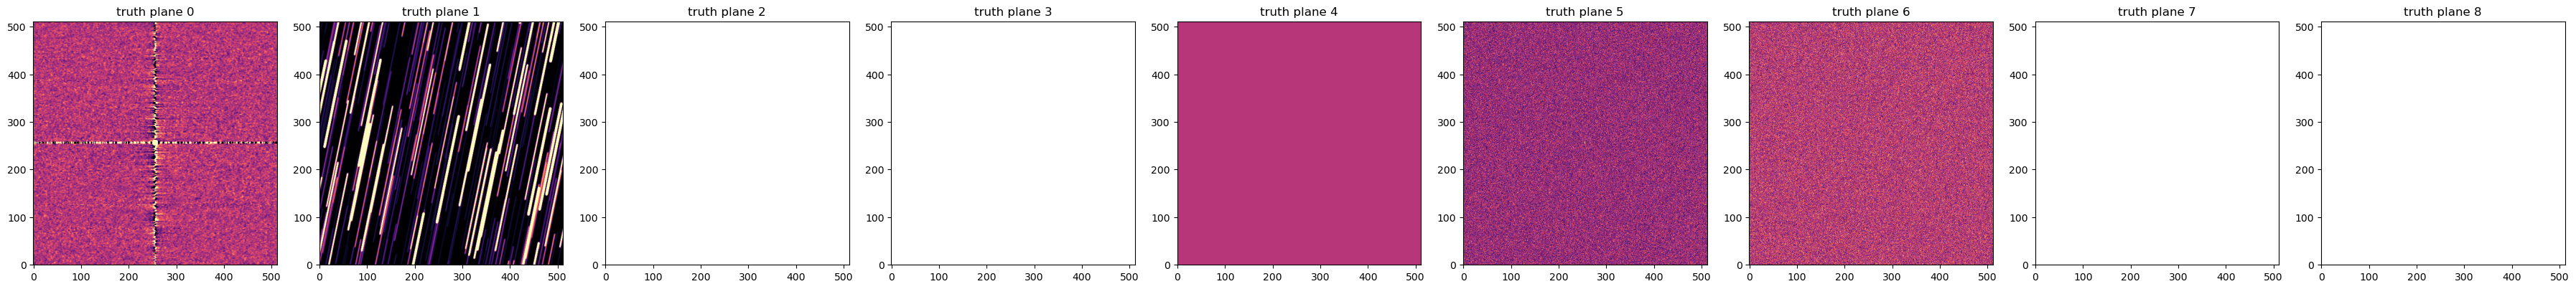

In [14]:
import tifffile

truth_path = os.path.join(run_dir, "Annotations", frame_stub + ".tiff")
truth = tifffile.imread(truth_path)
print("Ground-truth TIFF shape:", truth.shape, "dtype:", truth.dtype)
# Shape is typically (planes, H, W) or (H, W); show whatever planes exist.
planes = truth if truth.ndim == 3 else truth[None]
n = planes.shape[0]
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
axes = np.atleast_1d(axes)
for i, ax in enumerate(axes):
    pn = ImageNormalize(planes[i], interval=ZScaleInterval())
    ax.imshow(planes[i], origin="lower", cmap="magma", norm=pn)
    ax.set_title(f"truth plane {i}")
plt.tight_layout(); plt.show()

## 5. Reference: config structure

A quick lookup for the top-level keys. SatSim configs are JSON/YAML/`dict` and share this skeleton
(optional `clouds` and `radar` blocks omitted — `radar` *replaces* the EO render entirely).

```text
{
  "version": 1,
  "sim":        { ... rendering + output controls ... },
  "fpa":        { ... detector, optics, noise, timing ... },
  "background": { ... diffuse sky ... },
  "geometry":   { "time", "site", "stars", "obs" }
}
```

### `sim` — simulation & output
| key | typical | notes |
|---|---|---|
| `mode` | `fftconv2p` | render algorithm |
| `spatial_osf` | `3`–`5` | spatial oversampling |
| `temporal_osf` | `"auto"` or int | intra-exposure time steps |
| `padding` | `50`–`100` | oversampled-pixel border |
| `samples` | `1` | number of Monte-Carlo sets |
| `save_jpeg` / `save_movie` | `True` | annotated previews / animation |
| `save_ground_truth` | `False` | float32 truth `.tiff` planes |
| `save_czml` | `True` | Cesium scene export (later action item) |
| `enable_earth_shadow` | `False` | umbra masking of targets (off ⇒ always lit) |
| `star_annotation_threshold` | `False` | annotate stars brighter than this |

### `fpa` — focal-plane array
| key | notes |
|---|---|
| `height`, `width` | detector pixels |
| `y_fov`, `x_fov` | field of view (degrees) |
| `dark_current` | e⁻/pixel/s |
| `gain`, `bias` | pre-A/D gain, additive bias |
| `zeropoint` | magnitude → 1 pe/s |
| `a2d` | `{response, fwc, gain, bias}` A/D block |
| `noise` | `{read, electronic}` e⁻ RMS |
| `psf` | `{mode, eod}` (gaussian) or a poppy optical prescription |
| `time` | `{exposure, gap}` seconds |
| `num_frames` | frames per set |

### `geometry` — the physical scene
| key | notes |
|---|---|
| `time` | `[Y, M, D, h, m, s]` UTC start |
| `site.lat/lon/alt` | ground observer (deg, deg, km); or `tle`/`tle1`+`tle2` for a space-based observer |
| `site.gimbal.rotation` | focal-plane rotation |
| `site.track.mode` | `rate` \| `sidereal` \| `fixed` \| `radec` \| `rate-sidereal` |
| `stars.mode` | `bins` (synthetic histogram) \| `sstr7` / `csv` (real catalog) |
| `stars.mv.bins` / `.density` | **N+1 edges** / **N counts** (bins mode) |
| `stars.motion.mode` | `none` \| `affine` \| `affine-polar` |
| `obs.mode` | `list` |
| `obs.list[].mode` | `tle` \| `twobody` \| `gc` \| `ephemeris` \| `observation` \| `line` \| `line-polar` |
| `obs.list[].mv` (or `pe`) | object brightness — **required, or the object renders invisibly** |

### Object (`obs.list`) modes at a glance
| mode | how position is specified |
|---|---|
| `tle` | `tle: [line1, line2]` (or `tle1`, `tle2`) — SGP4 propagation |
| `twobody` | `position` + `velocity` (km, km/s) + `epoch` |
| `gc` | great-circle track |
| `ephemeris` | tabulated states |
| `line` / `line-polar` | abstract straight-line motion in **pixel** space (`origin`, `velocity`) — no astrometry, handy for quick tests |

---


## Appendix: config quirks & silent-failure surprises (collected)

SatSim does **no config schema validation**, so mistakes fail quietly. Everything here was reproduced
while building this notebook:

1. **Unknown / misspelled keys are ignored.** A typo'd `sim` key (e.g. `spatal_osf`) runs with no
   error and no effect — the real default silently stays in force.
2. **A target with no valid `mv`/`pe` renders with zero signal.** Put the brightness under the wrong
   key (`magnitude` instead of `mv`) and the target vanishes with no exception — the only hint is an
   unrelated `divide by zero encountered in log10` warning. Check the annotation object count and the
   frame itself.
3. **`stars.mv.bins` are edges, `density` are counts (N+1 vs N).** A mismatched pair is silently
   zipped; extra edges are dropped without warning.
4. **Annotation coordinates are normalized (0–1), not pixels.** Multiply by width/height before
   overlaying, or every object collapses into the corner.
5. **Illumination is not modeled unless you ask.** Targets render from their `mv` regardless of Earth
   shadow; enable `sim.enable_earth_shadow` for umbra masking.
6. **Stars render but aren't annotated by default.** Only `obs` targets appear in the annotation
   unless `sim.star_annotation_threshold` is set — the image and the label file disagree on purpose.
7. **`eager` argument is inert.** SatSim always runs eagerly; the parameter exists but "has no effect."
8. **Dependencies fail loudly but unhelpfully.** A missing transitive dependency surfaces only as a
   bare `ModuleNotFoundError` at `import satsim`. Install the full requirement set up front.

### Cross-check against the ADR / CLAUDE.md
Nothing in SatSim's real usage contradicts the ADR's characterization. Confirmed as described:
brightness is a **single scalar magnitude** per object (no wavelength axis) — consistent with the
ADR's "grey/scalar only, no color term" rationale for the hybrid pipeline. SatSim is
**TensorFlow-native** and always runs eagerly. Its native **CZML export** (`save_czml`) exists as the
ADR notes (we left it off; verifying its contents is Action Item 2). One environment caveat worth
recording: on **native Windows the TensorFlow build is CPU-only**, so SatSim's GPU acceleration is not
available here without WSL2 — relevant to any later throughput/differentiability work.
